In [ ]:
import pandas as pd
import numpy as np
housing = pd.read_csv("housing.csv")
housing.head(10)



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [ ]:
housing.dtypes


,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [ ]:
housing["median_income"].min(), housing["median_income"].max()


(0.0, 1.0)

In [ ]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)



In [ ]:
housing["income_cat"].isnull().sum()


np.int64(0)

In [ ]:
housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,0.476125,0.328572,0.541951,0.066986,0.083153,0.039869,0.081983,0.232464,0.395579
std,0.199555,0.226988,0.246776,0.055486,0.065083,0.031740,0.062873,0.131020,0.237928
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.253984,0.147715,0.333333,0.036771,0.045934,0.021974,0.045881,0.142308,0.215671
50%,0.583665,0.182784,0.549020,0.054046,0.067349,0.032596,0.067094,0.209301,0.339588
75%,0.631474,0.549416,0.705882,0.080014,0.099666,0.048264,0.099326,0.292641,0.514897
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
housing.median(numeric_only=True)


,0
longitude,0.583665
latitude,0.182784
housing_median_age,0.549020
total_rooms,0.054046
total_bedrooms,0.067349
population,0.032596
households,0.067094
median_income,0.209301
median_house_value,0.339588
ocean_proximity_INLAND,0.000000


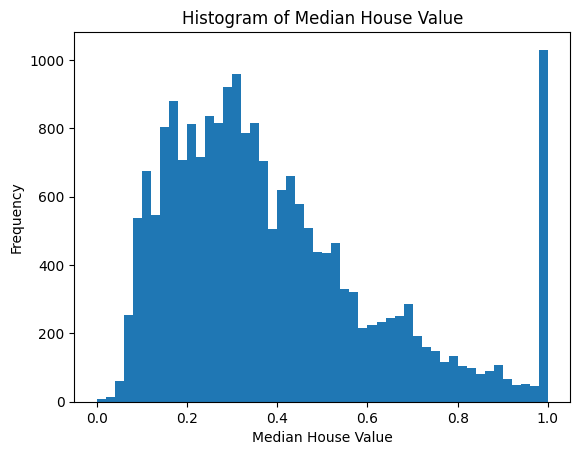

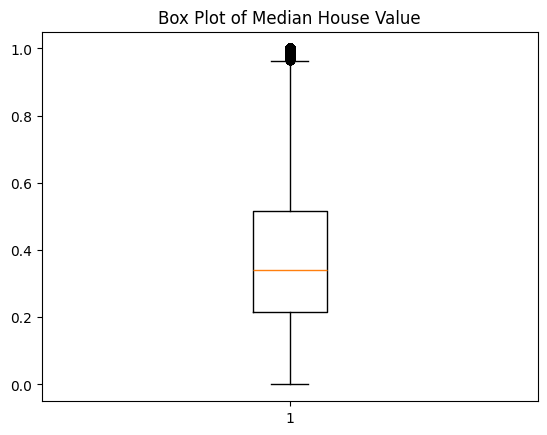

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(housing["median_house_value"], bins=50)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Histogram of Median House Value")
plt.show()
plt.boxplot(housing["median_house_value"])
plt.title("Box Plot of Median House Value")
plt.show()


In [ ]:
missing_count = housing.isnull().sum()
missing_percent = (missing_count / len(housing)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]


,Missing Count,Missing Percentage


In [ ]:
housing["total_bedrooms"].fillna(
    housing["total_bedrooms"].median(),
    inplace=True
)


/tmp/ipython-input-537539426.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(


In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler(feature_range=(0, 1))

num_cols = housing.select_dtypes(include=["int64", "float64"]).columns

housing[num_cols] = minmax_scaler.fit_transform(housing[num_cols])


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit



split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_idx]
    strat_test_set = housing.loc[test_idx]

housing.drop("income_cat", axis=1, inplace=True)


In [ ]:
corr_matrix = housing.corr()


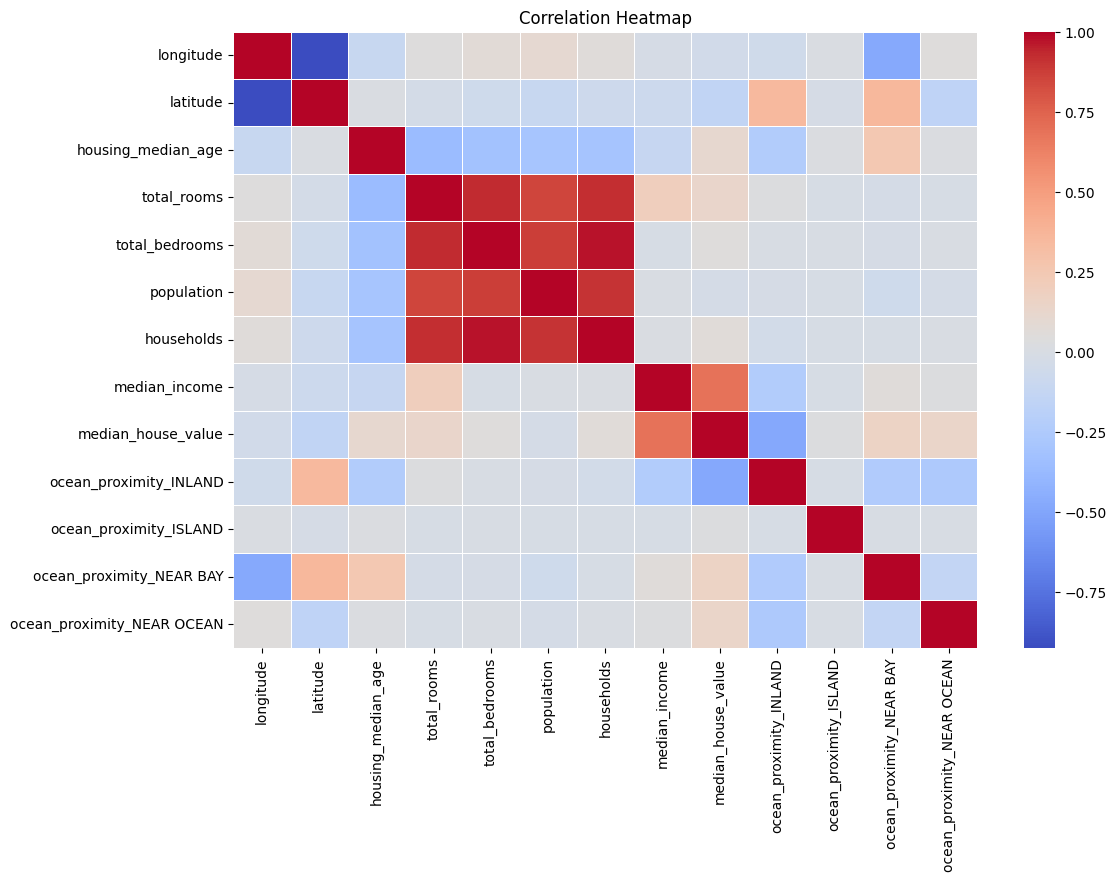

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


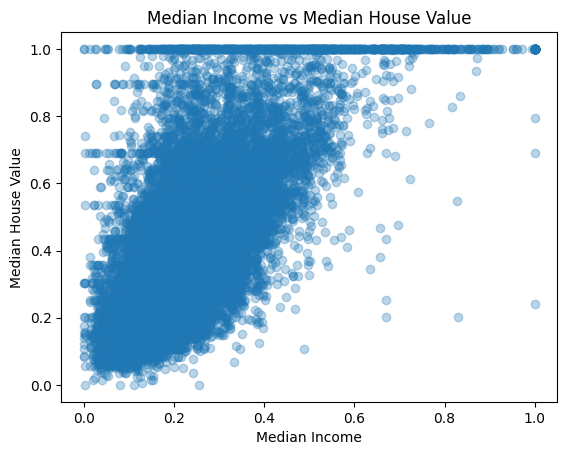

In [ ]:
plt.scatter(housing["median_income"], housing["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing, test_size=0.2, random_state=42
)


In [ ]:
corr_target = corr_matrix["median_house_value"].sort_values(ascending=False)
corr_target


,median_house_value
median_house_value,1.000000
median_income,0.688075
ocean_proximity_NEAR BAY,0.160284
ocean_proximity_NEAR OCEAN,0.141862
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049457
ocean_proximity_ISLAND,0.023416
population,-0.024650


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing[num_cols] = scaler.fit_transform(housing[num_cols])


In [ ]:
from sklearn.linear_model import LinearRegression

X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


RMSE: 0.6071480149230516
MAE: 0.43911517253426635
R2 Score: 0.6254240620553604
